In [2]:
import os 
os.chdir("D:/文章返修/source data/Figure_2/Panel_C")
from copy import copy
from matplotlib import colors
from scipy.signal import find_peaks
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#color palette
palette = copy(plt.cm.cividis)
palette.set_over('magenta', 1.0)
palette.set_under('black', 1.0)
palette.set_bad('magenta', 1.0)

#Load the color coding based on yeun-opencolors.
orfcolors = pd.read_csv('colorcode-rainbow-PEDV.txt', sep=' ', names=['orf', 'color'], index_col=0)['color'].to_dict()
print(orfcolors)

#load annotations
annotations = pd.read_csv('PEDV.bed', sep='\t',
                         names=['chrom', 'type', 'name', 'start', 'end', '_x', '_y', '_z'])
annotations['start'] -= 1

# Leader
cdsanno = annotations[(annotations['type'] == 'CDS') &
                      (~annotations['name'].isin(['ORF10', 'nsp1', 'frameshift'])) &
                      (~annotations['name'].apply(lambda x: x.startswith('nsp')))]

cdsanno = cdsanno.iloc[:, :5]
cdsanno

{'ORF1a': '#c5d9ea', 'ORF1b': '#e8d2c4', 'S': '#82c91e', 'ORF3': '#3bc9db', 'E': '#228be6', 'M': '#9fb1fc', 'N': '#ffd43b'}


,chrom,type,name,start,end
0,MK584552.1,CDS,ORF1a,292,12601
1,MK584552.1,CDS,ORF1b,12600,20637
2,MK584552.1,CDS,S,20633,24791
3,MK584552.1,CDS,ORF3,24790,25465
4,MK584552.1,CDS,E,25445,25676
5,MK584552.1,CDS,M,25683,26364
6,MK584552.1,CDS,N,26375,27701


In [4]:
largedels_nanopore = \
pd.read_csv('1_alpha_PEDV-14_PRJCA026550-rnaseq.1nt.none.matrix',
           names=[ 'j5', 'j3', 'score'], sep='\t')
#'test.bed.gz', compression='gzip','chrom', 'j5', 'j3', 'read_id', 'score', 'strand'
#largedels_nanopore

largedels_nanopore['j5'] = (largedels_nanopore['j5'] ).astype(int)
largedels_nanopore['j3'] = (largedels_nanopore['j3'] ).astype(int)

tilesize = 100
largedels_nanopore['j5_tile'] = ((largedels_nanopore['j5'] // tilesize) * tilesize ).astype(int)
largedels_nanopore['j3_tile'] = ((largedels_nanopore['j3'] // tilesize) * tilesize ).astype(int)

tiled_counts = \
largedels_nanopore.groupby(['j5_tile', 'j3_tile']).agg({
    'score': 'sum'}).reset_index()
trv = tiled_counts.pivot(index='j5_tile', columns='j3_tile', values=['score']).fillna(0).astype(int)
trv.to_csv('distribution of junction sites for PEDV genome.csv', sep=',', index=False, header=False)
trv

score                                                        ...  \
j3_tile 0     100   200   300   400   500   600   700   800   900    ...   
j5_tile                                                              ...   
0          32     3     4     6     1     5     4    29    19     0  ...   
100         0    77     4     5     3     8     2     3     5     0  ...   
200         0     0   123     2     3     2     5     4     6     1  ...   
300         0     0     0   185    22     8     8    26    19    15  ...   
400         0     0     0     0   198    22    18    26    24     2  ...   
...       ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
27600       0     0     0     0     0     0     0     0     0     0  ...   
27700       0     0     0     0     0     0     0     0     0     0  ...   
27800       0     0     0     0     0     0     0     0     0     0  ...   
27900       0     0     0     0     0     0     0     0     0     0  ...   
28000       0     0     0     0     0     0     0     0     0     0  ...   

                                                                        
j3_tile 27100 27200 27300  27400 27500 27600   27700 27800 27900 28000  
j5_tile                                                                 
0         598    96     9     35   143    28      19     6    19     0  
100         9     7     3     16    22    17       8     3     0     0  
200        14     9    13     42    67    11      21    11     1     0  
300       996   458  1200  11187  4499  3670   10488    31     7     1  
400       677   454  1737   9566  4940  5832   11195    17    11     0  
...       ...   ...   ...    ...   ...   ...     ...   ...   ...   ...  
27600       0     0     0      0     0  2834     293   169   145     7  
27700       0     0     0      0     0     0  214699   570    52     3  
27800       0     0     0      0     0     0       0  2015    66     4  
27900       0     0     0      0     0     0       0     0   926     0  
28000       0     0     0      0     0     0       0     0     0     2  

[281 rows x 281 columns]

2.0
2.1133289669060407


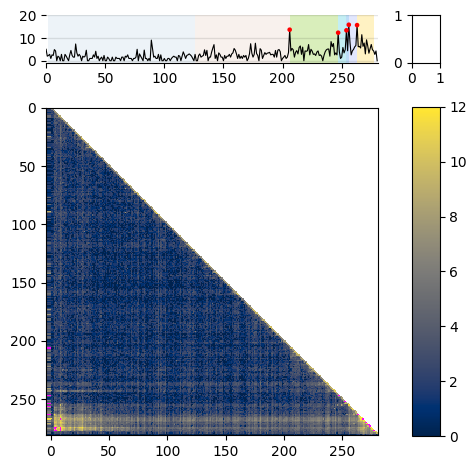

In [5]:
juncdensity = np.log2(trv+1).T.values.copy()
juncdensity.shape
juncdensity[np.triu_indices(juncdensity.shape[0], k=1, m=None)] = np.nan
juncdensity

PADSIZE = 4
jdpadded = np.hstack([juncdensity[:, :1]] * PADSIZE + [juncdensity])
jdpadded_mid = np.nanmedian(jdpadded)
jdpadded_mean = np.nanmean(jdpadded)
print(jdpadded_mid)
print(jdpadded_mean)

###########polt######################
COLORMAX = 12
NUMBINS = juncdensity.shape[0]

fig, axes = plt.subplots(2, 2, figsize=(4.8, 4.8),
                         gridspec_kw={'width_ratios': [12, 1], 'height_ratios': [1, 7]})

ax = axes[0, 0]
trsl_density = np.log2(trv['score'].iloc[0]+1).values

ax.plot(np.arange(len(trsl_density)), trsl_density, c='black', lw=.8, zorder=2)
for sp in 'top left right'.split():
    ax.spines[sp].set_visible(False)

peakpos = find_peaks(trsl_density, prominence=4, height=12)[0]

ax.scatter(peakpos , [trsl_density[p] for p in peakpos],
           c='red', s=11, edgecolor='none', zorder=3)
for _, cds in cdsanno.iterrows():
    color = orfcolors[cds['name']]
    ax.axvspan((cds['start'] // tilesize) , (cds['end'] // tilesize) , fc=color,
               alpha=.3)
ax.set_xticks(np.arange(0, NUMBINS+1, 50))
ax.set_xlim(0, NUMBINS)
ax.yaxis.grid(True, lw=1, c='black', alpha=.1)
ax.set_yticks(np.arange(0, 21, 10))

ax = axes[1, 0]
cbo = ax.pcolor(jdpadded, cmap=palette,
                norm=colors.Normalize(vmin=0, vmax=COLORMAX),
                rasterized=True)

ax.set_xticks(np.arange(0, NUMBINS + 1, 50) + PADSIZE)
ax.set_aspect(1)
ax.set_xlim(0, jdpadded.shape[1])
ax.set_xticklabels(np.arange(0, NUMBINS + 1, 50))
ax.invert_yaxis()

plt.colorbar(cbo, shrink=.6, cax=axes[1, 1])
plt.tight_layout()
plt.savefig('PEDV-14_PRJCA026550-rnaseq-1nt-none.pdf', dpi=600)

In [7]:
df = pd.DataFrame({"genome location":np.array(np.arange(len(trsl_density))),
                   "chimeric reads":trsl_density})

df.to_excel('distribution of 3\' breakpoints of chimeric reads.xlsx', index=False)